# Text Analytics Coursework

This notebook provides some example code for loading and examining the dataset for task 2. 

In [2]:
%load_ext autoreload
%autoreload 2

# Use HuggingFace's datasets library to access the Emotion dataset
from datasets import load_dataset
import numpy as np
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Task 2 - EBM-NLP

This dataset is provided at https://github.com/bepnye/EBM-NLP and a copy has been made available in this repository for convenience. The data will need to be unzipped:

In [3]:
import tarfile
import os

path_tofile = "/Users/ShreyaGouri/Desktop/masters/text_labs_public/coursework/ebm_nlp_2_00.tar.gz"
extract_directory = os.path.dirname(path_tofile)

if tarfile.is_tarfile(path_tofile):
    with tarfile.open(path_tofile, "r:gz") as f:
        f.extractall(path=extract_directory)  # Extract all members from the archive to the current working directory


The data contains text documents that are annotated for mentions of participants, interventions and outcomes (PIO) in medical research. For each entity type, P, I, or O, there is a slightly different set of documents in the training and test set. Most of the documents are identical, but each type has a few extra documents. So, let's deal with each type separately for now.

To load the text documents, we first make a list of the document IDs for one entity type (P, I or O):

In [4]:
from pathlib import Path

DATA_DIR = Path("/Users/ShreyaGouri/Desktop/masters/text_labs_public/coursework/ebm_nlp_2_00")

docs_dir = DATA_DIR / "documents"

def get_doc_ids(split="train", label_type="participants"):
    """ 
    split: 'train' or 'test' 
    """

    if split == "test":
        split = "test/gold"

    train_dir = (
        DATA_DIR
        / "annotations"
        / "aggregated"
        / "hierarchical_labels"
        / label_type  # assuming that the split is the same for all entity types, we can just look at one of them
        / split
    )
    
    doc_ids = [p.stem.split(".")[0] for p in train_dir.glob("*.AGGREGATED.ann")]
    print(doc_ids)
    return sorted(doc_ids)

doc_ids_p = get_doc_ids("train", "participants")
test_doc_ids_p = get_doc_ids("test", "participants")

print(f"Number of documents in train split for participants: {len(doc_ids_p)}")
print(f"Number of documents in test split for participants: {len(test_doc_ids_p)}")

['16730541', '23766737', '17715164', '1578953', '11547366', '125133', '25022248', '21978765', '4818631', '7814161', '11034934', '9587285', '6307704', '9761783', '23760519', '10197379', '22007005', '22638779', '15738536', '8499152', '11700823', '12123333', '11362629', '26317618', '11315533', '16089221', '23052635', '16864886', '6261782', '23874533', '11378833', '1990041', '8245359', '25225951', '20854436', '22917554', '8644646', '19232615', '7564450', '17868242', '25555877', '9394942', '1530836', '18512510', '16904970', '24281134', '352099', '9607867', '3859359', '18855271', '18635304', '7593098', '25629971', '22588803', '22485232', '17482439', '23361105', '3075724', '25040756', '11476129', '12546485', '8123947', '21574725', '14519754', '19931151', '3818024', '20598044', '1408861', '24061784', '22808053', '15889546', '8561059', '25807670', '23619951', '9751681', '25907208', '21097567', '21424566', '2968595', '18166533', '19897177', '21432860', '25733274', '24035299', '9088586', '1912717

Now, we can get the annotations for the first entity type:

In [5]:
def load_labels_for_doc(doc_id, label_type="participants", split="train"):
    """
    label_type: 'participants', 'interventions', or 'outcomes'
    split: 'train' or 'test' 
    """
    if split == "test":
        split = "test/gold"

    ann_path = DATA_DIR / "annotations" / "aggregated" / "hierarchical_labels" / label_type / split/ f"{doc_id}.AGGREGATED.ann"
    
    if not ann_path.exists():
        print(ann_path, "does not exist!")
        return None
    
    with open(ann_path, "r", encoding="utf-8") as f:
        labels = [line.strip() for line in f]
    
    return labels

def load_labels(doc_ids, label_type="participants", split="train"):
    labels = []
    for doc_id in doc_ids:
        doc_labels = load_labels_for_doc(doc_id, label_type, split)
        if doc_labels is not None:
            labels.append(doc_labels)
    return labels

participants_labels = load_labels(doc_ids_p, "participants", split="train")

print(f"Length of participants_labels: {len(participants_labels)}")

test_participants_labels = load_labels(test_doc_ids_p, "participants", split="test")
print(f"Length of test_participants_labels: {len(test_participants_labels)}")

sample = 123
print("Document ID:", doc_ids_p[sample])
print(f"Participants label example for doc {doc_ids_p[sample]}:")
print(participants_labels[sample])

Length of participants_labels: 4609
Length of test_participants_labels: 189
Document ID: 10674680
Participants label example for doc 10674680:
['0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '4', '4', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '1', '1', '1', '1', '1', '1', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '3', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '

In [6]:
from itertools import chain
import numpy as np

all_labels = chain(*participants_labels)

# show how many unique labels there are across the dataset
print(np.unique(list(all_labels)))

['0' '1' '2' '3' '4']


Let's look at what labels there are for Participants. The code above shows there are four values: 0 corresponds to 'outside' but 1-4 all indicate tokens that form an entity span. Each number is a level in a hierarchy of specificity. To start with let's not worry about this 'hierarchy'. We can instead just turn the labels into simple BIO (Beginning of a span, Inside a span, and Outside a span) tags.

In [7]:
def hierarchical_to_bio(tags):
    """
    Convert EBM-NLP hierarchical labels (0–4) to flat BIO tags.

    Parameters
    ----------
    tags : list[int]
        A list of hierarchical labels for a single document.

    Returns
    -------
    list[str]
        BIO tags ("O", "B", "I").
    """

    bio = []
    prev = 0

    for t in tags:
        t = int(t)  # ensure it's an integer
        if t == 0:
            bio.append("O")
        else:
            if prev == 0:
                bio.append("B")
            else:
                bio.append("I")

        prev = t
        

    return bio

def convert_all_labels_to_bio(labels):
    for i, doc_labels in enumerate(labels):
        labels[i] = hierarchical_to_bio(doc_labels)
    return labels

participants_labels = convert_all_labels_to_bio(participants_labels)
test_participants_labels = convert_all_labels_to_bio(test_participants_labels)

all_labels = chain(*participants_labels)

# show how many unique labels there are across the dataset
print(np.unique(list(all_labels)))

['B' 'I' 'O']


So far, we've loaded the document IDs for participants and the corresponding labels. Now, let's load the documents themselves. They are already tokenised so that the labels match up with the tokens:

In [8]:
def load_document(doc_id):
    doc_path = DATA_DIR / "documents" / f"{doc_id}.tokens"
    with open(doc_path, "r", encoding="utf-8") as f:
        return [line.strip() for line in f]

def load_documents(doc_ids):
    documents = []
    for doc_id in doc_ids:
        doc = load_document(doc_id)
        documents.append(doc)
    return documents

participants_tokens = load_documents(doc_ids_p)
test_participants_tokens = load_documents(test_doc_ids_p)

# inspect a random element
print("Document ID:", doc_ids_p[sample])
print(f"Tokenised document example for doc {doc_ids_p[sample]}:")
print(participants_tokens[sample])


Document ID: 10674680
Tokenised document example for doc 10674680:
['Assessment', 'of', 'therapeutic', 'response', 'of', 'Plasmodium', 'falciparum', 'to', 'chloroquine', 'and', 'sulfadoxine-pyrimethamine', 'in', 'an', 'area', 'of', 'low', 'malaria', 'transmission', 'in', 'Colombia', '.', 'Although', 'chloroquine', '(', 'CQ', ')', 'resistance', 'was', 'first', 'reported', 'in', 'Colombia', 'in', '1961', 'and', 'sulfadoxine-pyrimethamine', '(', 'SP', ')', 'resistance', 'in', '1981', ',', 'the', 'frequency', 'of', 'treatment', 'failures', 'to', 'these', 'drugs', 'in', 'Colombia', 'is', 'unclear', '.', 'A', 'modified', 'World', 'Health', 'Organization', '14-day', 'in', 'vivo', 'drug', 'efficacy', 'test', 'for', 'uncomplicated', 'Plasmodium', 'falciparum', 'malaria', 'in', 'areas', 'with', 'intense', 'malaria', 'transmission', 'was', 'adapted', 'to', 'reflect', 'the', 'clinical', 'and', 'epidemiologic', 'features', 'of', 'a', 'low-intensity', 'malaria', 'transmission', 'area', 'in', 'the', 

### Interventions

In [9]:
doc_ids_i = get_doc_ids("train", "interventions")
test_doc_ids_i = get_doc_ids("test", "interventions")

print(f"Number of documents in train split for interventions: {len(doc_ids_i)}")
print(f"Number of documents in test split for interventions: {len(test_doc_ids_i)}")

interventions_tokens = load_documents(doc_ids_i)
test_interventions_tokens = load_documents(test_doc_ids_i)

['16730541', '23766737', '1578953', '11547366', '125133', '25022248', '21978765', '4818631', '7814161', '11034934', '9587285', '6307704', '9761783', '23760519', '10197379', '22007005', '22638779', '15738536', '8499152', '11700823', '12123333', '11362629', '26317618', '11315533', '16089221', '23052635', '25795561', '24274627', '16864886', '19638081', '6261782', '23874533', '11378833', '26035186', '1990041', '8245359', '25225951', '20854436', '22917554', '8644646', '19232615', '7564450', '17868242', '25555877', '16006861', '9394942', '1530836', '18512510', '16904970', '24281134', '352099', '9607867', '3859359', '18855271', '18635304', '7593098', '25629971', '22588803', '22485232', '17482439', '23361105', '3075724', '25040756', '11476129', '12546485', '8123947', '21574725', '14519754', '19931151', '3818024', '20598044', '1408861', '24061784', '22808053', '15889546', '8561059', '25807670', '23619951', '9751681', '25907208', '21097567', '21424566', '2968595', '18166533', '19897177', '214328

In [10]:
interventions_labels = load_labels(doc_ids_i, "interventions", split="train")
print(f"Length of interventions_labels: {len(interventions_labels)}")

test_interventions_labels = load_labels(test_doc_ids_i, "interventions", split="test")
print(f"Length of test_interventions_labels: {len(test_interventions_labels)}")

interventions_labels = convert_all_labels_to_bio(interventions_labels)
test_interventions_labels = convert_all_labels_to_bio(test_interventions_labels)

Length of interventions_labels: 4746
Length of test_interventions_labels: 187


### Outcomes

In [11]:
doc_ids_o = get_doc_ids("train", "outcomes")
test_doc_ids_o = get_doc_ids("test", "outcomes")

print(f"Number of documents in train split for outcomes: {len(doc_ids_o)}")
print(f"Number of documents in test split for outcomes: {len(test_doc_ids_o)}")

outcomes_tokens = load_documents(doc_ids_o)
test_outcomes_tokens = load_documents(test_doc_ids_o)

['16730541', '23766737', '17715164', '1578953', '11547366', '125133', '25022248', '21978765', '4818631', '7814161', '11034934', '9587285', '6307704', '9761783', '10197379', '22007005', '22638779', '15738536', '8499152', '11700823', '12123333', '11362629', '11315533', '16089221', '23052635', '25795561', '24274627', '16864886', '19638081', '6261782', '23874533', '11378833', '26035186', '1990041', '8245359', '25225951', '20854436', '22917554', '8644646', '19232615', '7564450', '17868242', '25555877', '16006861', '9394942', '1530836', '18512510', '16904970', '24281134', '352099', '9607867', '3859359', '18855271', '18635304', '7593098', '25629971', '22588803', '22485232', '17482439', '23361105', '3075724', '25040756', '11476129', '12546485', '8123947', '21574725', '14519754', '19931151', '3818024', '20598044', '1408861', '24061784', '22808053', '15889546', '8561059', '25807670', '23619951', '9751681', '25907208', '21097567', '21424566', '2968595', '18166533', '19897177', '21432860', '240352

In [12]:
outcomes_labels = load_labels(doc_ids_o, "outcomes", split="train")
print(f"Length of outcomes_labels: {len(outcomes_labels)}")

test_outcomes_labels = load_labels(test_doc_ids_o, "outcomes", split="test")   
print(f"Length of test_outcomes_labels: {len(test_outcomes_labels)}")

outcomes_labels = convert_all_labels_to_bio(outcomes_labels)
test_outcomes_labels = convert_all_labels_to_bio(test_outcomes_labels)


Length of outcomes_labels: 4681
Length of test_outcomes_labels: 190


In [13]:
print(f"Intersection of train doc IDs across entity types: {len(set(doc_ids_p) & set(doc_ids_i) & set(doc_ids_o))}")
print(f"Intersection of test doc IDs across entity types: {len(set(test_doc_ids_p) & set(test_doc_ids_i) & set(test_doc_ids_o))}")
print(f"Documents that are different across entity types in train split: {len((set(doc_ids_p) | set(doc_ids_i) | set(doc_ids_o)) - (set(doc_ids_p) & set(doc_ids_i) & set(doc_ids_o)))}")
print(f"Documents that are different across entity types in test split: {len((set(test_doc_ids_p) | set(test_doc_ids_i) | set(test_doc_ids_o)) - (set(test_doc_ids_p) & set(test_doc_ids_i) & set(test_doc_ids_o)))}")


print(f"Test examples of the participants type that are in other entity types' training splits: {set(test_doc_ids_p) & (set(doc_ids_i) | set(doc_ids_o))}")
print(f"Test examples of the interventions type that are in other entity types' training splits: {set(test_doc_ids_i) & (set(doc_ids_p) | set(doc_ids_o))}")
print(f"Test examples of the outcomes type that are in other entity types' training splits: {set(test_doc_ids_o) & (set(doc_ids_p) | set(doc_ids_i))}")

Intersection of train doc IDs across entity types: 4457
Intersection of test doc IDs across entity types: 184
Documents that are different across entity types in train split: 344
Documents that are different across entity types in test split: 7
Test examples of the participants type that are in other entity types' training splits: set()
Test examples of the interventions type that are in other entity types' training splits: set()
Test examples of the outcomes type that are in other entity types' training splits: set()


## Sentence Embeddings & K-Means Clustering

Before building the pipeline: cluster sentences from the abstracts
to see whether natural groupings correspond to PICO schema fields.

- Split abstracts into sentences.
- Assign dominant PICO label to each sentence (P, I, O, or mixed/none) using the BIO annotations.
- Embed sentences with BERT (bert-base-uncased [CLS] token).
- Run K-Means with k=4 (P, I, O, plus a "background/mixed" cluster).
- Print sample sentences per cluster.
- PCA scatter plot coloured by actual label and cluster.

Hypothesis: Clinical trial abstracts follow a structured PICO format, so sentences
discussing each field should be semantically similar across documents. We expect
k=4 clusters to loosely align with P, I, O and a background cluster of sentences
that do not contain annotated spans.


### Step 1 – Split abstracts into sentences and assign PICO labels


In [14]:
import re
import numpy as np
import pandas as pd


def split_into_sentences(tokens, bio_labels):
    """
    Split a tokenised abstract into sentences using punctuation.
    The EBM-NLP data is already tokenised, so we detect
    sentence boundaries by looking for sentence-ending punctuation.

    Returns a list of dicts, each with:
    "tokens"  : list[str]  the tokens in this sentence
    "bio"     : list[str]  the corresponding BIO labels
    "text"    : str        the sentence as a single string
    """
    sentences = []
    current_tokens = []
    current_bio    = []

    for tok, tag in zip(tokens, bio_labels):
        current_tokens.append(tok)
        current_bio.append(tag)
        # sentence boundary: token is . ! ? and next token (if any) is capitalised
        if tok in (".", "!", "?") and len(current_tokens) >= 3:
            sentences.append({
                "tokens": current_tokens[:],
                "bio":    current_bio[:],
                "text":   " ".join(current_tokens),
            })
            current_tokens = []
            current_bio    = []

    # flush any remaining tokens as a final sentence
    if current_tokens:
        sentences.append({
            "tokens": current_tokens,
            "bio":    current_bio,
            "text":   " ".join(current_tokens),
        })
    return sentences


def dominant_label(bio_tags, label_name):
    """
    Given BIO tags for one PICO field in a sentence, return the field name
    if >30% of tokens are labelled, else return None.
    This 30% threshold avoids labelling sentences where only a single word matches.
    """
    n_labelled = sum(1 for t in bio_tags if t != "O")
    if len(bio_tags) > 0 and n_labelled / len(bio_tags) > 0.30:
        return label_name
    return None


def assign_sentence_label(p_bio, i_bio, o_bio):
    """
    Assign one of five labels to a sentence:
      "Participants", "Interventions", "Outcomes", "Mixed", or "Background"
    """
    labels = []
    if dominant_label(p_bio, "Participants"):  labels.append("Participants")
    if dominant_label(i_bio, "Interventions"): labels.append("Interventions")
    if dominant_label(o_bio, "Outcomes"):      labels.append("Outcomes")

    if len(labels) == 0:   return "Background"
    if len(labels) == 1:   return labels[0]
    return "Mixed"


# Build a sentence-level DataFrame from the train split, use documents that appear in ALL three entity splits so every sentence has all three annotation layers available.
common_doc_ids = sorted(set(doc_ids_p) & set(doc_ids_i) & set(doc_ids_o))
print(f"Documents with all three annotation layers (train): {len(common_doc_ids)}")

# Build lookup dicts: doc_id -> tokens / labels
p_token_map = dict(zip(doc_ids_p, participants_tokens))
i_token_map = dict(zip(doc_ids_i, interventions_tokens))
o_token_map = dict(zip(doc_ids_o, outcomes_tokens))
p_label_map = dict(zip(doc_ids_p, participants_labels))
i_label_map = dict(zip(doc_ids_i, interventions_labels))
o_label_map = dict(zip(doc_ids_o, outcomes_labels))

records = []
for doc_id in common_doc_ids:
    tokens  = p_token_map[doc_id]   # tokens are identical across entity types
    p_bio   = p_label_map[doc_id]
    i_bio   = i_label_map[doc_id]
    o_bio   = o_label_map[doc_id]

    sentences = split_into_sentences(tokens, p_bio)  # split using the token list

    # cursor to slice i_bio and o_bio aligned with each sentence
    cursor = 0
    for sent in sentences:
        n = len(sent["tokens"])
        sent_i_bio = i_bio[cursor: cursor + n]
        sent_o_bio = o_bio[cursor: cursor + n]
        label = assign_sentence_label(sent["bio"], sent_i_bio, sent_o_bio)
        records.append({"text": sent["text"], "label": label, "doc_id": doc_id})
        cursor += n

sent_df = pd.DataFrame(records)
print(f"Total sentences: {len(sent_df)}")
print(sent_df["label"].value_counts())
sent_df.head(8)


Documents with all three annotation layers (train): 4457
Total sentences: 47956
label
Background       38597
Outcomes          4561
Interventions     2636
Participants      1828
Mixed              334
Name: count, dtype: int64


,text,label,doc_id
0,[ Triple therapy regimens involving H2 blockad...,Background,10036953
1,Comparison of ranitidine and lansoprazole in s...,Background,10036953
2,To evaluate the efficacy and safety of two 1-w...,Background,10036953
3,The drug combination and administration period...,Background,10036953
4,"The ranitidine group received RNT 300 mg , CAM...",Background,10036953
5,The cure rate of H. pylori infection was 88 % ...,Background,10036953
6,Xylitol for prevention of acute otitis media .,Participants,10037531
7,Pre-operative short-term pulmonary rehabilitat...,Interventions,10052279


### Step 2 – sentence embeddings

embed each sentence using the `[CLS]` token from `bert-base-uncased`.
The `[CLS]` token aggregates the full sentence into a single 768-d vector.


In [15]:
from sentence_transformers import SentenceTransformer
import numpy as np

print("Loading sentence transformer model...")
model = SentenceTransformer('all-MiniLM-L6-v2')

def get_embeddings(texts):
    """
    Encode a list of sentence strings into embeddings.
    Returns a numpy array of shape (n_texts, 384).
    """
    embeddings = model.encode(texts, show_progress_bar=True)
    return np.array(embeddings)


SAMPLE_SIZE = 2000

if SAMPLE_SIZE and len(sent_df) > SAMPLE_SIZE:
    sample_df = sent_df.groupby("label", group_keys=False).apply(
        lambda x: x.sample(
            min(len(x), SAMPLE_SIZE // sent_df["label"].nunique()),
            random_state=42
        )
    ).reset_index(drop=True)
else:
    sample_df = sent_df.copy()

print(f"Embedding {len(sample_df)} sentences...")
print(sample_df["label"].value_counts())

embeddings = get_embeddings(sample_df["text"].tolist())
print(f"Embedding matrix shape: {embeddings.shape}")


Loading sentence transformer model...


/Users/shreyagouri/Desktop/masters/2025_26/.venv/lib/python3.9/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/var/folders/w4/z1stlhqn625g74twrnvd4p0m0000gp/T/ipykernel_55308/4075867965.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = sent_df.groupby("label", group_keys=False).apply(


Embedding 1934 sentences...
label
Background       400
Interventions    400
Outcomes         400
Participants     400
Mixed            334
Name: count, dtype: int64


Batches: 100%|██████████| 61/61 [00:35<00:00,  1.70it/s]

Embedding matrix shape: (1934, 384)


### Step 3 – K-Means clustering (k=4)

We use k=4: one cluster per PICO field (P, I, O) plus one for Background/Mixed sentences. Background/Mixed sentences are included as a way to deal with the limiting Comparators.


In [16]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import adjusted_rand_score

# Normalise so K-Means approximates cosine distance
X = normalize(embeddings)

K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_assignments = km.fit_predict(X)

# Encode true labels as integers for Adjusted Random Index
label_names = ["Participants", "Interventions", "Outcomes", "Background", "Mixed"]
label_to_int = {l: i for i, l in enumerate(label_names)}
true_int = sample_df["label"].map(label_to_int).values

ari = adjusted_rand_score(true_int, cluster_assignments)
print(f"K-Means k={K}  |  Adjusted Rand Index: {ari:.4f}")
print("(ARI = 0 means random; ARI = 1 means perfect alignment with true labels)")


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/Users/shreyagouri/Desktop/masters/2025_26/.venv/lib/python3.9/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


K-Means k=4  |  Adjusted Rand Index: 0.0167
(ARI = 0 means random; ARI = 1 means perfect alignment with true labels)


### Step 4 – Print sample sentences per cluster


In [17]:
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity

N_SAMPLES = 5  # sentences to print per cluster

print("=" * 70)
for c in range(K):
    mask = cluster_assignments == c
    cluster_texts  = sample_df["text"].values[mask]
    cluster_labels = sample_df["label"].values[mask]
    cluster_X      = X[mask]

    # majority true label and purity
    most_common_label, most_common_count = Counter(cluster_labels).most_common(1)[0]
    purity = most_common_count / len(cluster_labels)
    label_dist = dict(Counter(cluster_labels))

    # pick sentences closest to the centroid
    centroid = km.cluster_centers_[c].reshape(1, -1)
    sims = cosine_similarity(cluster_X, centroid).flatten()
    top_idx = sims.argsort()[::-1][:N_SAMPLES]

    print(f"\nCluster {c}  |  size={mask.sum()}  |  dominant label: {most_common_label}  |  purity={purity:.1%}")
    print(f"  Label distribution: {label_dist}")
    print(f"  {'─' * 60}")
    for idx in top_idx:
        print(f"  [{cluster_labels[idx]}]  {cluster_texts[idx][:120]}")

print("\n" + "=" * 70)



Cluster 0  |  size=649  |  dominant label: Interventions  |  purity=26.0%
  Label distribution: {'Background': 131, 'Interventions': 169, 'Mixed': 104, 'Outcomes': 114, 'Participants': 131}
  ────────────────────────────────────────────────────────────
  [Interventions]  PATIENTS AND METHODS A total of 210 patients were randomly assigned to one of three treatment arms : gemcitabine 1,250 m
  [Background]  RESULTS Two hundred twenty patients participated ( n = 107 , paricalcitol ; n = 113 , placebo ) .
  [Interventions]  Formoterol dose-dependently protected against methacholine responsiveness ( 4.6 doubling doses after 120 micrograms ) .
  [Interventions]  The patients were assigned at random to one of the following treatments : 1 ) Defibrotide at a dose of 400 mg b.i.d .
  [Interventions]  at the dose of 200 mg/week for 1 year .

Cluster 1  |  size=407  |  dominant label: Mixed  |  purity=26.5%
  Label distribution: {'Background': 57, 'Interventions': 97, 'Mixed': 108, 'Outcomes': 67

### Step 5 – PCA visualisation

Project the embeddings to 2D with PCA. Side-by-side:
left coloured by true PICO label, right coloured by K-Means cluster.


PCA variance explained: PC1=4.8%, PC2=3.1%


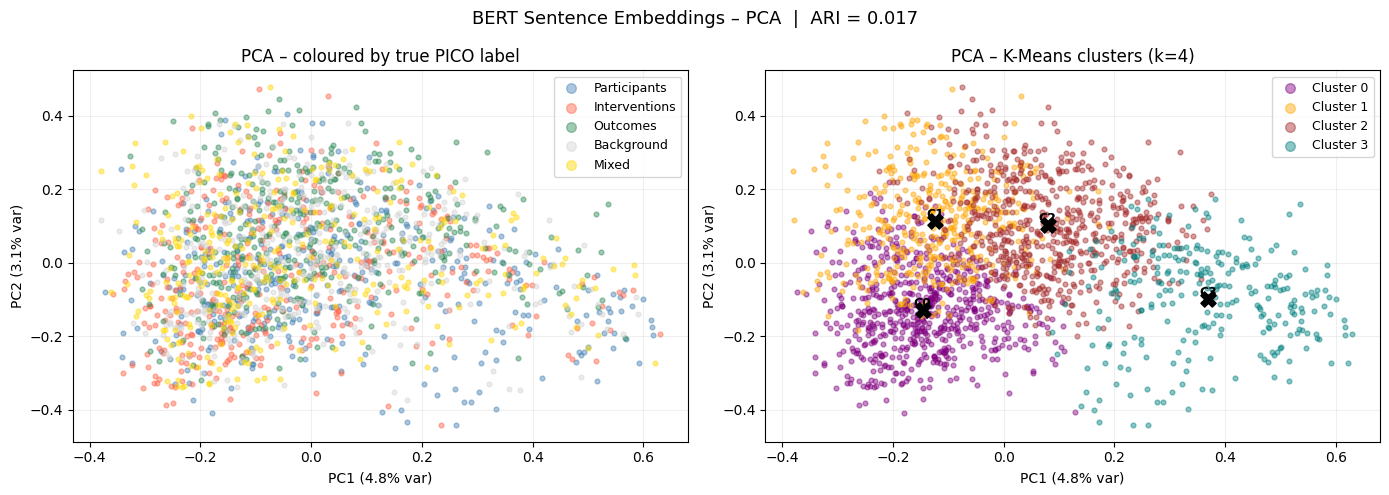

Plot saved to pca_bert_clusters.png


In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Fit PCA on the normalised embeddings
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)
var_explained = pca.explained_variance_ratio_
print(f"PCA variance explained: PC1={var_explained[0]:.1%}, PC2={var_explained[1]:.1%}")

TRUE_COLOURS = {
    "Participants":  "steelblue",
    "Interventions": "tomato",
    "Outcomes":      "seagreen",
    "Background":    "lightgray",
    "Mixed":         "gold",
}
CLUSTER_COLOURS = ["purple", "orange", "brown", "teal"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#  Left: true PICO labels
ax = axes[0]
for lbl, colour in TRUE_COLOURS.items():
    mask = sample_df["label"].values == lbl
    if mask.sum() == 0:
        continue
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=colour, label=lbl, alpha=0.45, s=12)
ax.set_title("PCA – coloured by true PICO label")
ax.set_xlabel(f"PC1 ({var_explained[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({var_explained[1]:.1%} var)")
ax.legend(markerscale=2, fontsize=9)
ax.grid(alpha=0.2)

#  Right: K-Means cluster assignments
ax = axes[1]
for c in range(K):
    mask = cluster_assignments == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=CLUSTER_COLOURS[c], label=f"Cluster {c}", alpha=0.45, s=12)
# annotate cluster centroids in PCA space
centroids_2d = pca.transform(km.cluster_centers_)
for c in range(K):
    ax.scatter(centroids_2d[c, 0], centroids_2d[c, 1],
               c="black", marker="X", s=120, zorder=5)
    ax.annotate(f"C{c}", xy=centroids_2d[c], fontsize=9,
                 ha="center", va="bottom", fontweight="bold")
ax.set_title(f"PCA – K-Means clusters (k={K})")
ax.set_xlabel(f"PC1 ({var_explained[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({var_explained[1]:.1%} var)")
ax.legend(markerscale=2, fontsize=9)
ax.grid(alpha=0.2)

plt.suptitle(
    f"BERT Sentence Embeddings – PCA  |  ARI = {ari:.3f}",
    fontsize=13
)
plt.tight_layout()
plt.savefig("pca_bert_clusters.png", dpi=150)
plt.show()
print("Plot saved to pca_bert_clusters.png")


In [20]:
#decomposed pipeline with weighted loss
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

#Prep data

X = sent_df["text"].tolist()
y = sent_df["label"].tolist()

print(f"\nTotal samples: {len(X)}")

#Efor embeddings, reuse model from clustering

print("Encoding sentences for classification...")
X_embed = model.encode(X, show_progress_bar=True)

print(f"Embedding shape: {X_embed.shape}")

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_embed,
    y,
    test_size=0.2,
    random_state=400,
    stratify=y
)

# train model
clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)
#uncomment to choose weights instead of balanced weight above (must comment those if running line underneath instead)
#clf = LogisticRegression(
    #max_iter=1000,
    #class_weight={
        #"Population": 1,
        #"Intervention": 2,
       # "Comparator": 3,
        #"Outcome": 2,
        #"Other": 0.5
    #}
#)
clf.fit(X_train, y_train)

# predict
y_pred = clf.predict(X_test)

# evaluate
print("\n CLASSIFICATION REPORT \n")
print(classification_report(y_test, y_pred))


Total samples: 47956
Encoding sentences for classification...


Batches: 100%|██████████| 1499/1499 [15:02<00:00,  1.66it/s]


Embedding shape: (47956, 384)

=== CLASSIFICATION REPORT ===

               precision    recall  f1-score   support

   Background       0.82      0.98      0.89      7720
Interventions       0.45      0.06      0.10       527
        Mixed       0.00      0.00      0.00        67
     Outcomes       0.64      0.15      0.24       912
 Participants       0.44      0.03      0.06       366

     accuracy                           0.81      9592
    macro avg       0.47      0.24      0.26      9592
 weighted avg       0.76      0.81      0.75      9592



/Users/shreyagouri/Desktop/masters/2025_26/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/shreyagouri/Desktop/masters/2025_26/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/shreyagouri/Desktop/masters/2025_26/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf

In [ ]:
#converting to spans, regex and heuristic span extraction within predicted sentences
import re

#regex patters
PARTICIPANT_PATTERNS = [
    r"\b(?:patients?|subjects?|participants?|adults?|children|women|men|infants|volunteers)\b(?:\s+\w+){0,8}",
    r"\b(?:elderly patients|healthy volunteers|postmenopausal women|older adults)\b",
    r"\b(?:patients?|subjects?|participants?)\s+with\b(?:\s+\w+){0,8}",
    r"\b(?:aged?|age)\s+\d+(?:\s*(?:to|-)\s*\d+)?(?:\s+years?)?\b"
]

INTERVENTION_PATTERNS = [
    r"\b(?:treated with|received|administered|given)\b(?:\s+\w+){1,10}",
    r"\b\d+(?:\.\d+)?\s?(?:mg|g|ml|mcg|μg|units)\b(?:\s+\w+){0,4}",
    r"\b(?:placebo|aspirin|metformin|insulin|warfarin|chemotherapy|radiotherapy|exercise|diet)\b(?:\s+\w+){0,6}",
    r"\b\w+\s+(?:therapy|treatment|supplementation|injection)\b(?:\s+\w+){0,5}"
]

OUTCOME_PATTERNS = [
    r"\b(?:reduction|improvement|increase|decrease)\s+in\b(?:\s+\w+){1,8}",
    r"\b(?:mortality|survival|response rate|remission|recurrence|blood pressure|hb1ac|hba1c|cholesterol)\b(?:\s+\w+){0,6}",
    r"\b(?:overall survival|progression free survival|quality of life)\b",
    r"\b(?:primary|secondary)\s+outcome\b(?:\s+\w+){0,6}"
]


#cleaning text

def clean_extracted_span(span):
    if span is None:
        return "NONE"

    span = span.strip(" ,.;:()[]{}\"'").strip()
    span = re.sub(r"\s+", " ", span)

    if not span:
        return "NONE"

    return span


#extraction using regex

def regex_extract_span(sentence_text, label_type):
    text = sentence_text.lower()

    if label_type == "participants":
        patterns = PARTICIPANT_PATTERNS
    elif label_type == "interventions":
        patterns = INTERVENTION_PATTERNS
    elif label_type == "outcomes":
        patterns = OUTCOME_PATTERNS
    else:
        return "NONE"

    for pattern in patterns:
        m = re.search(pattern, text)
        if m:
            return clean_extracted_span(m.group(0))

    return "NONE"


#fallback heuristics

def heuristic_extract_span(sentence_tokens, label_type):
    """
    Fallback if regex fails,
    Returns a short candidate phrase.
    """
    tokens_lower = [t.lower() for t in sentence_tokens]

    participant_cues = {
        "patient", "patients", "subject", "subjects", "participant", "participants",
        "adult", "adults", "children", "women", "men", "volunteers", "infants"
    }
    intervention_cues = {
        "treated", "received", "administered", "given", "placebo", "therapy",
        "treatment", "drug", "dose", "doses"
    }
    outcome_cues = {
        "reduction", "improvement", "increase", "decrease", "mortality",
        "survival", "response", "outcome", "pressure", "cholesterol"
    }

    if label_type == "participants":
        cues = participant_cues
        max_window = 6
    elif label_type == "interventions":
        cues = intervention_cues
        max_window = 7
    elif label_type == "outcomes":
        cues = outcome_cues
        max_window = 7
    else:
        return "NONE"

    for i, tok in enumerate(tokens_lower):
        if tok in cues:
            candidate = sentence_tokens[i:min(i + max_window, len(sentence_tokens))]
            return clean_extracted_span(" ".join(candidate))

    #fallback - first 4->6 non-punctuation tokens
    filtered = [t for t in sentence_tokens if re.search(r"\w", t)]
    if filtered:
        return clean_extracted_span(" ".join(filtered[:5]))

    return "NONE"


# choosing best span per sentences

def extract_span_from_sentence(sentence_tokens, sentence_text, label_type):
    span = regex_extract_span(sentence_text, label_type)

    if span != "NONE":
        return span

    return heuristic_extract_span(sentence_tokens, label_type)


#extracted span into token-level bio

def span_to_bio(sentence_tokens, extracted_span):
    """
    Match extracted span back to tokens and label only that subsequence.
    """
    if extracted_span == "NONE":
        return ["O"] * len(sentence_tokens)

    span_tokens = extracted_span.lower().split()
    sent_tokens = [t.lower() for t in sentence_tokens]

    best_start = -1
    best_len = 0

    #longest contiguous match
    for i in range(len(sent_tokens)):
        cur_len = 0
        while (
                i + cur_len < len(sent_tokens)
                and cur_len < len(span_tokens)
                and sent_tokens[i + cur_len] == span_tokens[cur_len]
        ):
            cur_len += 1

        if cur_len > best_len:
            best_len = cur_len
            best_start = i

    bio = ["O"] * len(sentence_tokens)

    if best_start != -1 and best_len > 0:
        bio[best_start] = "B"
        for j in range(best_start + 1, best_start + best_len):
            bio[j] = "I"
        return bio

    #softer fallback: mark cue tokens individually
    used_b = False
    for i, tok in enumerate(sent_tokens):
        if tok in span_tokens:
            bio[i] = "B" if not used_b else "I"
            used_b = True

    return bio


#building output data for label type (only one)

def build_output_data_for_label_type(label_type):
    label_name_map = {
        "participants": "Participants",
        "interventions": "Interventions",
        "outcomes": "Outcomes"
    }

    target_sentence_label = label_name_map[label_type]

    pred_doc_ids = []
    pred_tokens = []
    gold_labels = []
    pred_labels = []

    for doc_id in common_test_doc_ids:
        tokens, gold = get_tokens_and_gold(doc_id, label_type)

        p_bio = test_p_label_map[doc_id]
        # sentence splitting needs the aligned token count; p_bio is fine because tokens are shared
        sentences = split_into_sentences(tokens, p_bio)

        doc_pred_labels = []

        for sent in sentences:
            sent_text = sent["text"]
            sent_tokens = sent["tokens"]

            sent_embed = model.encode([sent_text])
            sent_pred = clf.predict(sent_embed)[0]

            if sent_pred == target_sentence_label:
                extracted_span = extract_span_from_sentence(
                    sent_tokens,
                    sent_text,
                    label_type
                )
                sent_token_labels = span_to_bio(sent_tokens, extracted_span)
            else:
                sent_token_labels = ["O"] * len(sent_tokens)

            doc_pred_labels.extend(sent_token_labels)

        doc_pred_labels = doc_pred_labels[:len(tokens)]

        pred_doc_ids.append(doc_id)
        pred_tokens.append(tokens)
        gold_labels.append(gold)
        pred_labels.append(doc_pred_labels)

    return {
        "label_type": label_type,
        "doc_ids": pred_doc_ids,
        "tokens": pred_tokens,
        "gold_labels": gold_labels,
        "pred_labels": pred_labels
    }


#building output for p, i and o

output_data_p = build_output_data_for_label_type("participants")
output_data_i = build_output_data_for_label_type("interventions")
output_data_o = build_output_data_for_label_type("outcomes")

#display
print("\nPARTICIPANTS\n")
print(output_data_p["label_type"])
print(output_data_p["doc_ids"][0])
print(output_data_p["tokens"][0][:10])
print(output_data_p["gold_labels"][0][:10])
print(output_data_p["pred_labels"][0][:10])

print("\nINTERVENTIONS\n")
print(output_data_i["label_type"])
print(output_data_i["doc_ids"][0])
print(output_data_i["tokens"][0][:10])
print(output_data_i["gold_labels"][0][:10])
print(output_data_i["pred_labels"][0][:10])

print("\nOUTCOMES\n")
print(output_data_o["label_type"])
print(output_data_o["doc_ids"][0])
print(output_data_o["tokens"][0][:10])
print(output_data_o["gold_labels"][0][:10])
print(output_data_o["pred_labels"][0][:10])